# 07_understand_panderm_frozen_prototypes_baseline1

This notebook is a **walk-through notebook** for **Baseline 1: Frozen PanDerm + class prototypes**.

It mirrors `scripts/eval_panderm_frozen_prototypes.py`, but here the goal is **understanding** rather than only reporting final metrics.

## What this notebook shows
1. How the official CSV is read and split into train / eval
2. How one image is loaded and transformed
3. How PanDerm Base is built and how the checkpoint is loaded
4. What the important model parts are
5. What tensor shapes look like at different stages
6. How frozen features are extracted
7. How class prototypes are computed from train embeddings
8. How one eval image is classified with cosine similarity
9. Why **nothing is backpropagated** in this baseline


In [1]:
from pathlib import Path
import json
import random
import sys
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message=r'Importing from timm\.models\.layers is deprecated, please import via timm\.layers', category=FutureWarning)
warnings.filterwarnings('ignore', message=r'Importing from timm\.models\.registry is deprecated, please import via timm\.models', category=FutureWarning)
warnings.filterwarnings('ignore', message=r'torch\.meshgrid: in an upcoming release, it will be required to pass the indexing argument\.', category=UserWarning)


## Config

Choose either HAM or BCN by changing `CSV_PATH` and `ROOT_PATH`.

This notebook expects the same processed CSV format as the official PanDerm processed datasets with columns like `image`, `label`, and `split`.


In [2]:
REPO_ROOT = Path('..').resolve()
PANDERM_CLASSIFICATION_DIR = (REPO_ROOT / 'external' / 'PanDerm' / 'classification').resolve()
if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

from models.builder import get_norm_constants  # type: ignore
from models.modeling_finetune import panderm_base_patch16_224_finetune  # type: ignore

CSV_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'HAM10000.csv'
ROOT_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'images'
# CSV_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'bcn20000.csv'
# ROOT_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'images'

CHECKPOINT_PATH = REPO_ROOT / 'external' / 'weights' / 'panderm_bb_data6_checkpoint-499.pth'
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 0
SEED = 42
EVAL_SPLIT = 'test'
MAX_TRAIN_IMAGES_FOR_DEMO = None  # set e.g. 2000 if you want a quicker demo

OUT_DIR = REPO_ROOT / 'outputs' / 'baseline1_understanding'
OUT_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print('DEVICE:', DEVICE)
print('CSV_PATH exists:', CSV_PATH.exists(), CSV_PATH)
print('ROOT_PATH exists:', ROOT_PATH.exists(), ROOT_PATH)
print('CHECKPOINT_PATH exists:', CHECKPOINT_PATH.exists(), CHECKPOINT_PATH)


DEVICE: mps
CSV_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv
ROOT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images
CHECKPOINT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('Seeded with:', SEED)


Seeded with: 42


## Load CSV and inspect splits

In [4]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())

train_df = df[df['split'].astype(str).str.lower() == 'train'].copy()
eval_df = df[df['split'].astype(str).str.lower() == EVAL_SPLIT].copy()

if MAX_TRAIN_IMAGES_FOR_DEMO is not None:
    train_df = train_df.sample(min(MAX_TRAIN_IMAGES_FOR_DEMO, len(train_df)), random_state=SEED).sort_index().copy()

print('train_df:', train_df.shape)
print('eval_df:', eval_df.shape)
print('\nTrain label counts:')
print(train_df['label'].value_counts().sort_index())
print('\nEval label counts:')
print(eval_df['label'].value_counts().sort_index())


Shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old


train_df: (8207, 13)
eval_df: (1232, 13)

Train label counts:
label
0     273
1     448
2     941
3     102
4    1021
5    5304
6     118
Name: count, dtype: int64

Eval label counts:
label
0     35
1     44
2    107
3      8
4     70
5    951
6     17
Name: count, dtype: int64


## One example image
We first inspect a single eval image before any transform.

lesion_id            HAM_0006071
image_id            ISIC_0032343
dx                           bkl
dx_type                    histo
age                         70.0
sex                       female
localization                face
dataset             vidir_modern
split                       test
label                          2
image           ISIC_0032343.jpg
binary_label                   0
age_group                    old
Name: 8783, dtype: object

Example path: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images/ISIC_0032343.jpg
Original PIL size: (600, 450)


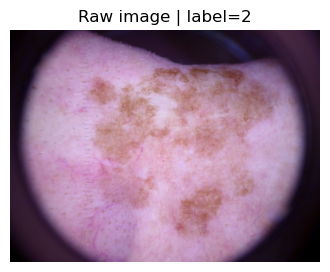

In [5]:
example_row = eval_df.iloc[0].copy()
example_path = ROOT_PATH / str(example_row['image'])
print(example_row)
print('\nExample path:', example_path)

with Image.open(example_path) as img:
    img_rgb = img.convert('RGB')
    print('Original PIL size:', img_rgb.size)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f'Raw image | label={example_row["label"]}')
    plt.axis('off')
    plt.show()


## Transform used before the model
This matches the baseline script: resize to 256, center crop to 224, convert to tensor, normalize with ImageNet mean/std.

normalization method:  imagenet
Normalization mean: (0.485, 0.456, 0.406)
Normalization std: (0.228, 0.224, 0.225)
Transformed tensor shape: (3, 224, 224)
Tensor dtype: torch.float32
Tensor min/max: -1.8781511783599854 2.3088455200195312


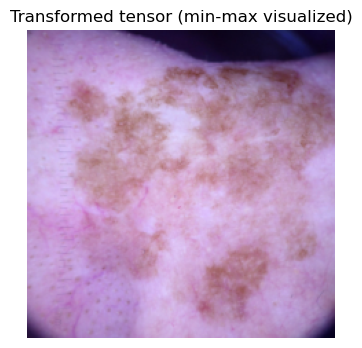

In [6]:
def build_eval_transform(image_size: int):
    mean, std = get_norm_constants('imagenet')
    print('Normalization mean:', mean)
    print('Normalization std:', std)
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

eval_transform = build_eval_transform(IMAGE_SIZE)
img_tensor = eval_transform(img_rgb)
print('Transformed tensor shape:', tuple(img_tensor.shape))
print('Tensor dtype:', img_tensor.dtype)
print('Tensor min/max:', float(img_tensor.min()), float(img_tensor.max()))

plt.figure(figsize=(4, 4))
vis = img_tensor.permute(1, 2, 0).cpu().numpy()
vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)
plt.imshow(vis)
plt.title('Transformed tensor (min-max visualized)')
plt.axis('off')
plt.show()


## Dataset and dataloader
The dataloader yields image tensor, numeric label, and small metadata dict.

In [7]:
def safe_open_image(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert('RGB')

class CSVImageDataset(Dataset):
    def __init__(self, df, root_path: Path, image_col='image', label_col='label', transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.root_path = root_path
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.root_path / str(row[self.image_col])
        img = safe_open_image(image_path)
        img = self.transform(img)
        label = int(row[self.label_col])
        meta = {'image': str(row[self.image_col]), 'label': label}
        return img, label, meta

train_ds = CSVImageDataset(train_df, ROOT_PATH, transform=eval_transform)
eval_ds = CSVImageDataset(eval_df, ROOT_PATH, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

one_batch = next(iter(train_loader))
batch_images, batch_labels, batch_meta = one_batch
print('Batch image tensor shape:', tuple(batch_images.shape))
print('Batch labels shape:', tuple(batch_labels.shape))
print('First batch meta example:', {k: batch_meta[k][0] for k in batch_meta})


Batch image tensor shape: (64, 3, 224, 224)
Batch labels shape: (64,)
First batch meta example: {'image': 'ISIC_0027419.jpg', 'label': tensor(2)}


## Build the PanDerm model and load the checkpoint
This baseline uses PanDerm as a **frozen encoder**. There is no optimizer and no backward pass.

In [8]:
def build_model(num_classes=1):
    model = panderm_base_patch16_224_finetune(
        pretrained=False,
        num_classes=num_classes,
        drop_rate=0.0,
        drop_path_rate=0.1,
        attn_drop_rate=0.0,
        drop_block_rate=None,
        use_mean_pooling=False,
        init_scale=0.001,
        use_rel_pos_bias=False,
        init_values=1e-5,
        lin_probe=False,
    )
    return model

def load_pretrained_backbone(model, checkpoint_path: Path):
    state_dict = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print('=' * 80)
    print('PanDerm checkpoint loading report')
    print('=' * 80)
    print('Missing keys:', len(missing))
    if missing:
        print('First missing keys:', missing[:20])
    print('Unexpected keys:', len(unexpected))
    if unexpected:
        print('First unexpected keys:', unexpected[:20])

model = build_model(num_classes=1)
load_pretrained_backbone(model, CHECKPOINT_PATH)
model = model.to(DEVICE)
model.eval()

print('\nModel class:', model.__class__.__name__)
print('Has forward_features:', hasattr(model, 'forward_features'))
print('Patch embed module:', type(model.patch_embed).__name__ if hasattr(model, 'patch_embed') else 'N/A')
print('Number of transformer blocks:', len(model.blocks) if hasattr(model, 'blocks') else 'N/A')
print('cls_token shape:', tuple(model.cls_token.shape) if hasattr(model, 'cls_token') else 'N/A')
print('pos_embed shape:', tuple(model.pos_embed.shape) if hasattr(model, 'pos_embed') else 'N/A')
print('head module:', model.head if hasattr(model, 'head') else 'N/A')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}')
print(f'Trainable params flag-wise: {trainable_params:,}')
print('Important note: even if params are marked trainable by default, this baseline still does not update them because no backward or optimizer step is used.')


PanDerm checkpoint loading report
Missing keys: 2
First missing keys: ['head.weight', 'head.bias']
Unexpected keys: 0

Model class: VisionTransformer
Has forward_features: True
Patch embed module: PatchEmbed
Number of transformer blocks: 12
cls_token shape: (1, 1, 768)
pos_embed shape: (1, 197, 768)
head module: Linear(in_features=768, out_features=1, bias=True)
Total params: 85,808,641
Trainable params flag-wise: 85,657,345
Important note: even if params are marked trainable by default, this baseline still does not update them because no backward or optimizer step is used.


# *Note*
- `forward_features: True`: model has a method called forward_features() and there is a function to get internal features before the classifier head. This is very useful in the baseline because we want embeddings, not logits. In short: feature extraction is available!

In [9]:
summary_rows = []
if hasattr(model, 'patch_embed'):
    summary_rows.append({'part': 'patch_embed', 'type': type(model.patch_embed).__name__})
summary_rows.append({'part': 'cls_token', 'type': str(tuple(model.cls_token.shape)) if hasattr(model, 'cls_token') else 'N/A'})
summary_rows.append({'part': 'pos_embed', 'type': str(tuple(model.pos_embed.shape)) if hasattr(model, 'pos_embed') else 'N/A'})
summary_rows.append({'part': 'transformer_blocks', 'type': len(model.blocks) if hasattr(model, 'blocks') else 'N/A'})
if hasattr(model, 'norm'):
    summary_rows.append({'part': 'norm', 'type': type(model.norm).__name__})
if hasattr(model, 'fc_norm'):
    summary_rows.append({'part': 'fc_norm', 'type': type(model.fc_norm).__name__})
summary_rows.append({'part': 'head', 'type': type(model.head).__name__ if hasattr(model, 'head') else 'N/A'})
display(pd.DataFrame(summary_rows))


,part,type
0,patch_embed,PatchEmbed
1,cls_token,"(1, 1, 768)"
2,pos_embed,"(1, 197, 768)"
3,transformer_blocks,12
4,norm,LayerNorm
5,fc_norm,NoneType
6,head,Linear


## Forward hooks for temporary shapes
We attach hooks to a few important modules so we can inspect tensor shapes during one forward pass.

In [10]:
shape_log = []
hooks = []

def register_shape_hook(module, name):
    def hook(module, inputs, output):
        in_shape = []
        for x in inputs:
            if torch.is_tensor(x):
                in_shape.append(tuple(x.shape))
            elif isinstance(x, (list, tuple)):
                in_shape.append(str(type(x)))
            else:
                in_shape.append(type(x).__name__)

        if torch.is_tensor(output):
            out_shape = tuple(output.shape)
        elif isinstance(output, tuple):
            out_shape = [tuple(o.shape) if torch.is_tensor(o) else type(o).__name__ for o in output]
        else:
            out_shape = type(output).__name__

        shape_log.append({
            'module': name,
            'input_shape': in_shape,
            'output_shape': out_shape
        })
    return module.register_forward_hook(hook)

if getattr(model, 'patch_embed', None) is not None:
    hooks.append(register_shape_hook(model.patch_embed, 'patch_embed'))

if getattr(model, 'blocks', None) is not None and len(model.blocks) > 0:
    hooks.append(register_shape_hook(model.blocks[0], 'block_0'))
    hooks.append(register_shape_hook(model.blocks[-1], 'block_last'))

if getattr(model, 'norm', None) is not None:
    hooks.append(register_shape_hook(model.norm, 'norm'))

if getattr(model, 'fc_norm', None) is not None:
    hooks.append(register_shape_hook(model.fc_norm, 'fc_norm'))

if getattr(model, 'head', None) is not None:
    hooks.append(register_shape_hook(model.head, 'head'))

single_x = img_tensor.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    _ = model(single_x)

for h in hooks:
    h.remove()

shape_df = pd.DataFrame(shape_log)
display(shape_df)

,module,input_shape,output_shape
0,patch_embed,"[(1, 3, 224, 224)]","(1, 196, 768)"
1,block_0,"[(1, 197, 768)]","(1, 197, 768)"
2,block_last,"[(1, 197, 768)]","(1, 197, 768)"
3,norm,"[(1, 197, 768)]","(1, 197, 768)"
4,head,"[(1, 768)]","(1, 1)"


# *Note*
- Before the head module, the model reduces the token sequence to one feature vector (usually by selecting the final CLS representation). So the classifier head works on a single image representation, not on all 197 tokens. That one vector is what the head classifies.

## Important clarification: inspection forward vs real baseline forward

The hook-based forward pass above uses:

- `model(single_x)`

This is useful only to inspect the **full architecture**, including the classifier head.

But **Baseline 1 does not use the head output for prediction**.

The real baseline pipeline is:

1. call `model.forward_features(x)`
2. get the embedding / feature vector
3. L2-normalize the feature
4. compare it to class prototypes with cosine similarity
5. take the argmax similarity as the predicted class

So the `head` shown in the hook table is part of the model architecture, but it is **not the decision rule used in Baseline 1**.

In [21]:
## Explicit comparison: forward_features() vs model()

with torch.no_grad():
    feats_direct = model.forward_features(single_x)
    logits_direct = model(single_x)

print("Output of model.forward_features(single_x):")
if torch.is_tensor(feats_direct):
    print("  type: Tensor")
    print("  shape:", tuple(feats_direct.shape))
else:
    print("  type:", type(feats_direct).__name__)

print("\nOutput of model(single_x):")
if torch.is_tensor(logits_direct):
    print("  type: Tensor")
    print("  shape:", tuple(logits_direct.shape))
else:
    print("  type:", type(logits_direct).__name__)

print("\nInterpretation:")
print("- model.forward_features(single_x) gives the representation used for Baseline 1 embeddings.")
print("- model(single_x) runs the full network including the classifier head.")
print("- Baseline 1 uses the embedding path, not the classifier-head logits path.")

Output of model.forward_features(single_x):
  type: Tensor
  shape: (1, 768)

Output of model(single_x):
  type: Tensor
  shape: (1, 1)

Interpretation:
- model.forward_features(single_x) gives the representation used for Baseline 1 embeddings.
- model(single_x) runs the full network including the classifier head.
- Baseline 1 uses the embedding path, not the classifier-head logits path.


## Manual feature extraction logic
This cell mirrors the baseline script exactly.

In [12]:
@torch.no_grad()
def extract_features_debug(model, images: torch.Tensor):
    debug = {}

    if hasattr(model, 'forward_features'):
        feats = model.forward_features(images)
        debug['used_forward_features'] = True
    else:
        feats = model(images)
        debug['used_forward_features'] = False

    debug['raw_output_type'] = type(feats).__name__
    if torch.is_tensor(feats):
        debug['raw_output_shape'] = tuple(feats.shape)
    elif isinstance(feats, tuple):
        debug['raw_output_shape'] = [tuple(x.shape) if torch.is_tensor(x) else type(x).__name__ for x in feats]

    if isinstance(feats, tuple):
        feats = feats[0]
        debug['tuple_reduced_to_first'] = True
        debug['after_tuple_shape'] = tuple(feats.shape) if torch.is_tensor(feats) else type(feats).__name__
    else:
        debug['tuple_reduced_to_first'] = False

    if feats.ndim == 3:
        debug['token_sequence_shape'] = tuple(feats.shape)
        if feats.shape[1] > 1:
            feats = feats[:, 0]
            debug['cls_taken'] = True
            debug['after_cls_shape'] = tuple(feats.shape)
        else:
            feats = feats.mean(dim=1)
            debug['mean_pooled_single_token_sequence'] = True
            debug['after_pool_shape'] = tuple(feats.shape)

    if feats.ndim > 2:
        feats = feats.flatten(start_dim=1)
        debug['flattened'] = True
        debug['after_flatten_shape'] = tuple(feats.shape)
    else:
        debug['flattened'] = False

    feats_before_norm = feats.clone()
    feats = F.normalize(feats, dim=1)
    debug['final_feature_shape'] = tuple(feats.shape)
    debug['norm_before'] = torch.norm(feats_before_norm, dim=1).cpu().numpy().tolist()
    debug['norm_after'] = torch.norm(feats, dim=1).cpu().numpy().tolist()

    return feats, debug

single_feat, single_debug = extract_features_debug(model, single_x)
print(json.dumps(single_debug, indent=2))
print('Final single feature shape:', tuple(single_feat.shape))


{
  "used_forward_features": true,
  "raw_output_type": "Tensor",
  "raw_output_shape": [
    1,
    768
  ],
  "tuple_reduced_to_first": false,
  "flattened": false,
  "final_feature_shape": [
    1,
    768
  ],
  "norm_before": [
    15.424509048461914
  ],
  "norm_after": [
    0.9999999403953552
  ]
}
Final single feature shape: (1, 768)


## What is backpropagated here?
**Nothing.** This baseline is pure inference / feature extraction. There is no loss, no optimizer, no `backward()`, and no parameter update.

In [13]:
print('Any optimizer defined? -> No')
print('Any loss.backward() called? -> No')
print('Feature extraction uses torch.no_grad()? -> Yes')
print('So are gradients used in baseline 1? -> No')


Any optimizer defined? -> No
Any loss.backward() called? -> No
Feature extraction uses torch.no_grad()? -> Yes
So are gradients used in baseline 1? -> No


## Collect train and eval features

In [14]:
@torch.no_grad()
def collect_features(model, loader, device):
    model.eval()
    all_feats = []
    all_labels = []
    all_meta = []

    for images, labels, meta in tqdm(loader, desc='extract_features', leave=False):
        images = images.to(device, non_blocking=(device == 'cuda'))
        feats, _ = extract_features_debug(model, images)
        all_feats.append(feats.cpu())
        all_labels.append(labels.cpu())
        all_meta.extend([{k: meta[k][i] for k in meta} for i in range(len(labels))])

    feats = torch.cat(all_feats, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return feats, labels, all_meta

train_feats, train_labels, train_meta = collect_features(model, train_loader, DEVICE)
eval_feats, eval_labels, eval_meta = collect_features(model, eval_loader, DEVICE)

print('train_feats shape:', tuple(train_feats.shape))
print('eval_feats shape:', tuple(eval_feats.shape))
print('Unique classes in train:', sorted(train_labels.unique().tolist()))


extract_features:   0%|          | 0/129 [00:00<?, ?it/s]

extract_features:   0%|          | 0/20 [00:00<?, ?it/s]

train_feats shape: (8207, 768)
eval_feats shape: (1232, 768)
Unique classes in train: [0, 1, 2, 3, 4, 5, 6]


## Compute class prototypes
A prototype is the mean normalized feature vector for one class.

In [15]:
def build_class_prototypes(train_feats: torch.Tensor, train_labels: torch.Tensor):
    prototypes = {}
    rows = []
    for cls in sorted(train_labels.unique().tolist()):
        cls_mask = train_labels == cls
        cls_feats = train_feats[cls_mask]
        proto = cls_feats.mean(dim=0, keepdim=True)
        proto = F.normalize(proto, dim=1).squeeze(0)
        prototypes[int(cls)] = proto
        rows.append({
            'class_id': int(cls),
            'n_train_images': int(cls_mask.sum().item()),
            'prototype_shape': tuple(proto.shape),
            'prototype_norm': float(torch.norm(proto).item()),
        })
    return prototypes, pd.DataFrame(rows)

prototypes, proto_df = build_class_prototypes(train_feats, train_labels)
display(proto_df)


,class_id,n_train_images,prototype_shape,prototype_norm
0,0,273,"(768,)",1.0
1,1,448,"(768,)",1.0
2,2,941,"(768,)",1.0
3,3,102,"(768,)",1.0
4,4,1021,"(768,)",1.0
5,5,5304,"(768,)",1.0
6,6,118,"(768,)",1.0


## Inspect one example classification in detail
For one eval image, extract feature, compare to every class prototype, and choose the largest cosine similarity.

In [16]:
example_eval_idx = 0
example_eval_image, example_eval_label, example_eval_meta = eval_ds[example_eval_idx]
example_eval_x = example_eval_image.unsqueeze(0).to(DEVICE)
example_eval_feat, example_eval_debug = extract_features_debug(model, example_eval_x)

class_ids = sorted(prototypes.keys())
proto_mat = torch.stack([prototypes[c] for c in class_ids], dim=0)
sims = (example_eval_feat.cpu() @ proto_mat.T).squeeze(0)
pred_class = class_ids[int(torch.argmax(sims).item())]

detail_df = pd.DataFrame({
    'class_id': class_ids,
    'cosine_similarity': sims.numpy(),
}).sort_values('cosine_similarity', ascending=False).reset_index(drop=True)

print('True class:', example_eval_label)
print('Predicted class:', pred_class)
print('Metadata:', example_eval_meta)
display(detail_df)


True class: 2
Predicted class: 4
Metadata: {'image': 'ISIC_0032343.jpg', 'label': 2}


,class_id,cosine_similarity
0,4,0.960708
1,2,0.957791
2,3,0.954462
3,1,0.953941
4,0,0.953075
5,5,0.951221
6,6,0.941220


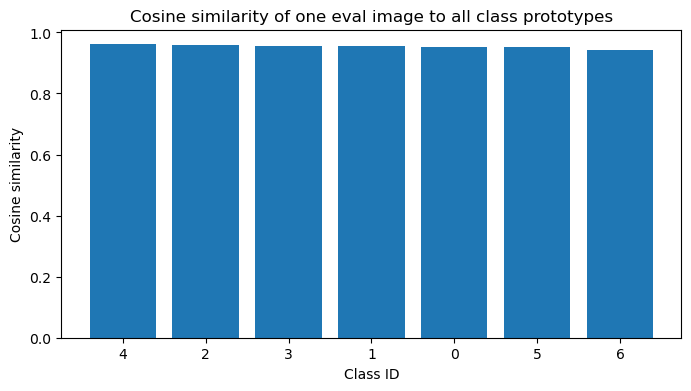

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(detail_df['class_id'].astype(str), detail_df['cosine_similarity'])
plt.title('Cosine similarity of one eval image to all class prototypes')
plt.xlabel('Class ID')
plt.ylabel('Cosine similarity')
plt.show()


## Full baseline prediction on the eval split

In [18]:
def predict_by_cosine(feats: torch.Tensor, prototypes: dict):
    class_ids = sorted(prototypes.keys())
    proto_mat = torch.stack([prototypes[c] for c in class_ids], dim=0)
    sims = feats @ proto_mat.T
    pred_idx = sims.argmax(dim=1).cpu().numpy()
    preds = np.array([class_ids[i] for i in pred_idx], dtype=int)
    return preds

preds = predict_by_cosine(eval_feats, prototypes)
y_true = eval_labels.numpy()

metrics = {
    'accuracy': float(accuracy_score(y_true, preds)),
    'balanced_accuracy': float(balanced_accuracy_score(y_true, preds)),
    'macro_f1': float(f1_score(y_true, preds, average='macro', zero_division=0)),
    'mcc': float(matthews_corrcoef(y_true, preds)),
}

print(json.dumps(metrics, indent=2))


{
  "accuracy": 0.6428571428571429,
  "balanced_accuracy": 0.49359062799945563,
  "macro_f1": 0.3418277391396175,
  "mcc": 0.36961297325532405
}


## Save a debug summary JSON
Useful later when you build the Mermaid flowchart.

In [19]:
# debug_summary = {
#     'baseline_name': 'Frozen PanDerm + class prototypes',
#     'csv_path': str(CSV_PATH),
#     'root_path': str(ROOT_PATH),
#     'checkpoint_path': str(CHECKPOINT_PATH),
#     'device': DEVICE,
#     'train_rows': int(len(train_df)),
#     'eval_rows': int(len(eval_df)),
#     'train_feature_shape': list(train_feats.shape),
#     'eval_feature_shape': list(eval_feats.shape),
#     'n_classes': int(len(prototypes)),
#     'prototype_dim': int(next(iter(prototypes.values())).numel()),
#     'single_image_debug': example_eval_debug,
#     'metrics': metrics,
#     'key_takeaway': 'No backpropagation is used. The encoder stays frozen. Prediction is done by cosine similarity to class prototypes computed from train embeddings.'
# }

# debug_json_path = OUT_DIR / 'baseline1_debug_summary.json'
# with open(debug_json_path, 'w', encoding='utf-8') as f:
#     json.dump(debug_summary, f, indent=2)

# print('Saved debug summary to:', debug_json_path)


## Mermaid-ready textual summary

### Actual Baseline 1 pipeline
1. Raw image
2. Resize to 256
3. Center crop to 224
4. Convert to tensor
5. Normalize with ImageNet mean/std
6. Pass through **frozen PanDerm encoder**
7. Use `forward_features()` to obtain image representation
8. Convert representation to final feature vector
9. L2-normalize feature vector
10. Compute one prototype per class from **train** embeddings
11. Compute cosine similarity between eval feature and all prototypes
12. Argmax over similarities
13. Final predicted class

### Important note
The classifier head exists in the architecture, but **Baseline 1 does not use the head logits for prediction**.

In [20]:
print("MERMAID SUMMARY")
print("- Raw image")
print("- Transform: resize 256 -> center crop 224 -> tensor -> normalize")
print("- Frozen PanDerm Base encoder")
print("- Use forward_features() to obtain embedding")
print("- Convert embedding to final feature vector")
print("- L2 normalization")
print("- Build one class prototype per class from train embeddings")
print("- Cosine similarity between eval feature and all prototypes")
print("- Argmax over similarities")
print("- Final predicted class")
print("- Classifier head exists in the architecture but is not used for the Baseline 1 decision rule")
print("- No backpropagation, no optimizer, no weight update")

MERMAID SUMMARY
- Raw image
- Transform: resize 256 -> center crop 224 -> tensor -> normalize
- Frozen PanDerm Base encoder
- Use forward_features() to obtain embedding
- Convert embedding to final feature vector
- L2 normalization
- Build one class prototype per class from train embeddings
- Cosine similarity between eval feature and all prototypes
- Argmax over similarities
- Final predicted class
- Classifier head exists in the architecture but is not used for the Baseline 1 decision rule
- No backpropagation, no optimizer, no weight update
